# Figure 3 Jupyter Notebook

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import glob
import os

from lmfit import Model

## Subfigure (a): Photon Pair Storage

In [2]:
FILENAME = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_03_30/afc_longterm/afc_storage_experiment.npz')
FILENAME_OFFRES = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                   '/Mounted_device_mk_5/10mK/2026_03_31/afc_longterm/afc_storage_experiment.npz')

data_pairs = np.load(FILENAME)
data_pairs_offres = np.load(FILENAME_OFFRES)
coincidence = data_pairs["counts"]
coincidence_offres = data_pairs_offres["counts"]
time = data_pairs["bins"]

center = time[np.argmax(coincidence)]
time -= center

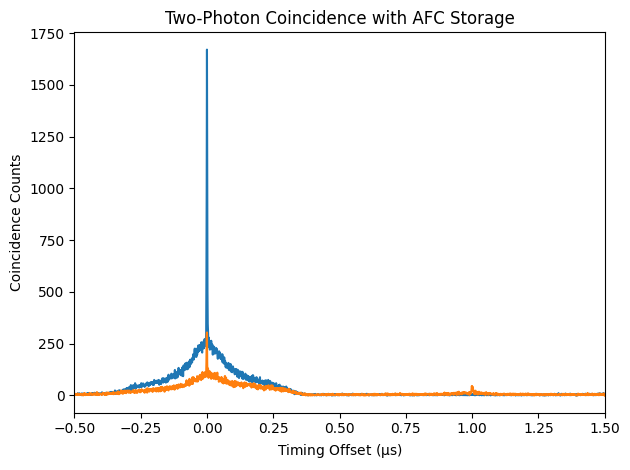

In [3]:
xlim = -0.5, 1.5

plt.plot(time, coincidence_offres)
plt.plot(time, coincidence)
plt.xlim(xlim)
plt.xlabel(r"Timing Offset ($\mathrm{\mu}$s)")
plt.ylabel("Coincidence Counts")
plt.title("Two-Photon Coincidence with AFC Storage")
plt.tight_layout()

Also define inset for echo counts

/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_49577/2475491222.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


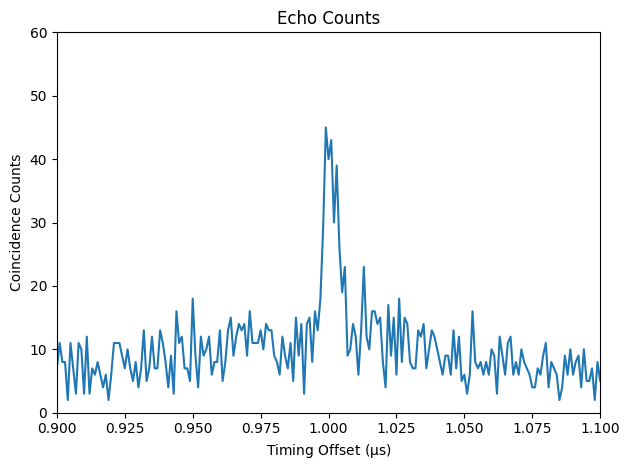

In [4]:
xlim_echo = 0.9, 1.1
ylim_echo = 0, 60

fig, ax = plt.subplots()

ax.plot(time, coincidence)
ax.set_xlim(xlim_echo)
ax.set_ylim(ylim_echo)
ax.set_xlabel(r"Timing Offset ($\mathrm{\mu}$s)")
ax.set_ylabel("Coincidence Counts")
ax.set_title("Echo Counts")

fig.tight_layout()
fig.show()

## Subfigure (b): Coincidence Interference

In [5]:
DATA_CONSTRUCTIVE = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                     '/Unmounted_device_mk_3/2026_04_15/pair_generation/interference_350mV_negP_5min.txt')
DATA_DESTRUCTIVE = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                    '/Unmounted_device_mk_3/2026_04_15/pair_generation/interference_210mV_5min.txt')
num_bins = 10

df_constructive = pd.read_csv(DATA_CONSTRUCTIVE, sep='\t')
df_destructive = pd.read_csv(DATA_DESTRUCTIVE, sep='\t')

time_interference = df_constructive['Time(ps)']
time_interference *= 1e-3  # convert to ns

center_bin = np.argmax(df_constructive['Counts'])
idx_start = center_bin - num_bins // 2
idx_end = center_bin + num_bins // 2 + 1

counts_constructive = np.sum(df_constructive['Counts'][idx_start:idx_end])
counts_destructive = np.sum(df_destructive['Counts'][idx_start:idx_end])
visibility = (counts_constructive - counts_destructive) / (counts_constructive + counts_destructive)
print(f'Visibility: {visibility*100:.2f}%')

Visibility: 90.39%


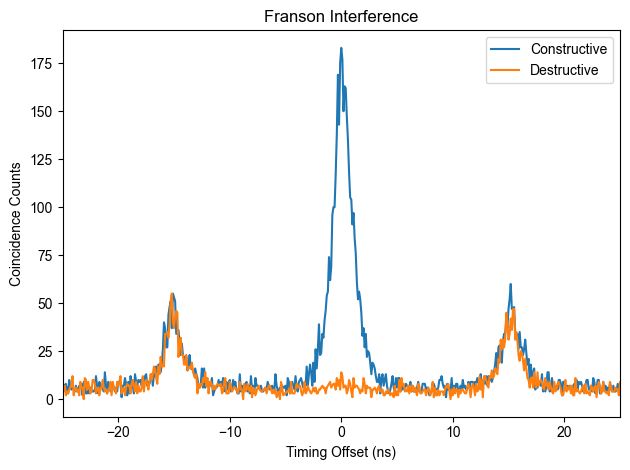

In [16]:
center_time_interference = time_interference[center_bin]

plt.plot(time_interference-center_time_interference, df_constructive['Counts'],
         label='Constructive')
plt.plot(time_interference-center_time_interference, df_destructive['Counts'],
         label='Destructive')
plt.title('Franson Interference')
plt.xlabel('Timing Offset (ns)')
plt.ylabel('Coincidence Counts')
plt.legend()
plt.xlim((-25, 25))
plt.tight_layout()

## Subfigure (c): Pair Storage Interference

In [7]:
DIRS_CONSTRUCTIVE = [('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                      '/Mounted_device_mk_5/10mK/2026_03_23/afc_longterm'),
                     ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                      '/Mounted_device_mk_5/10mK/2026_03_26/afc_longterm'),
                     ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                      '/Mounted_device_mk_5/10mK/2026_03_27/afc_longterm')]
FILES_TO_INCLUDE_CONSTRUCTIVE = [12, 6, 2]
DIRS_DESTRUCTIVE = [('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                     '/Mounted_device_mk_5/10mK/2026_03_21/afc_longterm'),
                    ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                     '/Mounted_device_mk_5/10mK/2026_03_25/afc_longterm')]
FILES_TO_INCLUDE_DESTRUCTIVE = [12, 15]

# plotting params
xlim_input = (-0.1, 0.1)
xlim_echo = (0.9, 1.1)
ylim_input = (0, 1200)
ylim_echo = (0, 150)


def sort_func(filename):
    file_parts = filename.split('_')
    try:
        return int(file_parts[-1].split('.')[0])
    except ValueError:
        return 0


all_counts_constructive = []
all_bins_constructive = []
for num_files, dir in zip(FILES_TO_INCLUDE_CONSTRUCTIVE, DIRS_CONSTRUCTIVE):
    all_files = glob.glob(os.path.join(dir, '*.npz'))
    all_files.sort(key=sort_func)

    # load data and plot individual files (constructive)
    all_bins = []
    all_counts = []
    all_freqs = []
    all_file_numbers = []
    for file in all_files:
        file_number = sort_func(file)
        all_file_numbers.append(file_number)

        data = np.load(file)
        counts = data['counts']
        bins = data['bins']
        freqs_start = data['freq_start']
        freqs_end = data['freq_end']
        all_counts.append(counts)
        all_bins.append(bins)
        all_freqs.append((freqs_start, freqs_end))

    all_counts_constructive += all_counts[:num_files]
    all_bins_constructive += all_bins[:num_files]


all_counts_destructive = []
all_bins_destructive = []
for num_files, dir in zip(FILES_TO_INCLUDE_DESTRUCTIVE, DIRS_DESTRUCTIVE):
    all_files = glob.glob(os.path.join(dir, '*.npz'))
    all_files.sort(key=sort_func)

    # load data and plot individual files (constructive)
    all_bins = []
    all_counts = []
    all_freqs = []
    all_file_numbers = []
    for file in all_files:
        file_number = sort_func(file)
        all_file_numbers.append(file_number)

        data = np.load(file)
        counts = data['counts']
        bins = data['bins']
        freqs_start = data['freq_start']
        freqs_end = data['freq_end']
        all_counts.append(counts)
        all_bins.append(bins)
        all_freqs.append((freqs_start, freqs_end))

    all_counts_destructive += all_counts[:num_files]
    all_bins_destructive += all_bins[:num_files]

# display number of files
print('Number of Constructive Files: ', len(all_counts_constructive))
print('Number of Destructive Files: ', len(all_counts_destructive))

# find center using constructive interference
bins = all_bins_constructive[0]
center = bins[np.argmax(all_counts_constructive[0])]
bins -= center

all_hist_constructive = np.sum(all_counts_constructive, axis=0)
all_hist_destructive = np.sum(all_counts_destructive, axis=0)

Number of Constructive Files:  20
Number of Destructive Files:  27


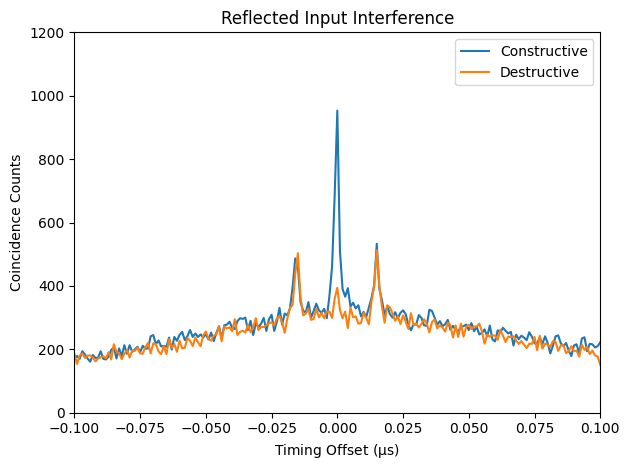

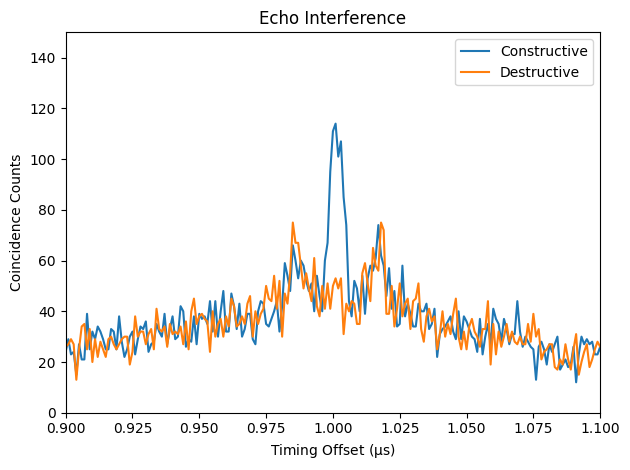

In [9]:
# plot just input
plt.plot(bins, all_hist_constructive, label='Constructive')
plt.plot(bins, all_hist_destructive, label='Destructive')
plt.xlim(xlim_input)
plt.ylim(ylim_input)
plt.xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
plt.ylabel('Coincidence Counts')
plt.title('Reflected Input Interference')
plt.legend()
plt.tight_layout()
plt.show()

# plot just echo
plt.plot(bins, all_hist_constructive, label='Constructive')
plt.plot(bins, all_hist_destructive, label='Destructive')
plt.xlim(xlim_echo)
plt.ylim(ylim_echo)
plt.ylim(ylim_echo)
plt.xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
plt.ylabel('Coincidence Counts')
plt.title('Echo Interference')
plt.legend()
plt.tight_layout()
plt.show()

# Main Plot Code

First, define plotting parameters

In [44]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 8})
figsize = (8, 3)  # inches
dpi = 100
include_subplot_titles = False

# colors
color_primary = '#7570b3'
color_secondary = '#d95f02'
color_tertiary = '#1b9e77'

# figure layout
horizontal_ratios = (1.5, 1, 1)
vertical_padding = 0.05
horizontal_padding = 0.05

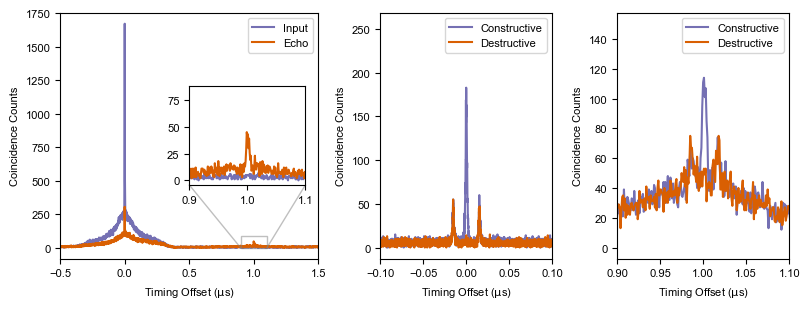

In [51]:
fig = plt.figure(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)
axs = fig.subplots(1, 3, width_ratios=horizontal_ratios)

xlim_pair = -0.5, 1.5
xlim_pair_echo = 0.9, 1.1
axs[0].plot(time, coincidence_offres,
            color=color_primary, label='Input')
axs[0].plot(time, coincidence,
            color=color_secondary, label='Echo')
axs[0].set_xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
axs[0].set_ylabel("Coincidence Counts")
axs[0].set_xlim(xlim_pair)
axs[0].legend()
axs_0_ylim = axs[0].get_ylim()
echo_scaling_factor = 0.05  # approximately equal to efficiency
ylim_pair_echo = tuple(y * 0.05 for y in axs_0_ylim)
axs_0_inset = axs[0].inset_axes([0.5, 0.3, 0.45, 0.4],
                                xlim=xlim_pair_echo, ylim=ylim_pair_echo,)
axs_0_inset.plot(time, coincidence_offres, color=color_primary)
axs_0_inset.plot(time, coincidence, color=color_secondary)
axs[0].indicate_inset_zoom(axs_0_inset)

xlim_pair_interference = (-0.1, 0.1)
axs[1].plot((time_interference-center_time_interference)/1e3, df_constructive['Counts'],
            color=color_primary, label='Constructive')
axs[1].plot((time_interference-center_time_interference)/1e3, df_destructive['Counts'],
            color=color_secondary, label='Destructive')
axs[1].set_xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
axs[1].set_ylabel('Coincidence Counts')
axs[1].set_xlim(xlim_pair_interference)
axs[1].legend()
old_ylim = axs[1].get_ylim()
factor = 1.4
axs[1].set_ylim((old_ylim[0]*factor, old_ylim[1]*factor))

axs_2_ylim = tuple(y * 0.09 for y in axs_0_ylim)
axs[2].plot(bins, all_hist_constructive,
            color=color_primary, label='Constructive')
axs[2].plot(bins, all_hist_destructive,
            color=color_secondary, label='Destructive')
axs[2].set_xlim(xlim_echo)
axs[2].set_ylim(axs_2_ylim)
axs[2].set_xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
axs[2].set_ylabel('Coincidence Counts')
axs[2].legend()